# Поиск статей справки по пользовательскому запросу

### Описание подхода

Задача тут не сгенерировать готовый ответ а сначала найти статьи которые стоит передать дальше в RAG пайплайн. Для каждого запроса нужно вернуть до 10 `article_id` в правильном порядке. Основная метрика это `MAP@10`.

#### 1. Подготовка статей

Сначала я посмотрел из каких тегов состоит HTML и отдельно проверил подписи у картинок. Дальше статьи разбиваются по смысловым секциям: заголовки становятся границами а текст из `tabset` и `spoiler` не теряется.

После этого секции режутся на небольшие чанки по 150 слов с overlap 30 слов. В текст чанка добавляется название статьи и секции. Так поиск понимает не только отдельный абзац но и его контекст

#### 2. Поисковые признаки

Использую сразу несколько сигналов:

- BM25 по заголовкам и чанкам
- char TF-IDF по заголовкам и чанкам
- эмбеддинги `Qwen/Qwen3-Embedding-0.6B` по заголовкам и чанкам

BM25 хорошо ловит конкретные слова. char TF-IDF помогает с опечатками и похожими формулировками, а Qwen ищет уже по смыслу.

#### 3. Кандидаты и переранжирование

Сначала статьи объединяются через RRF. На этом этапе главная цель не идеально расставить top-10 а не потерять релеватные статьи в candidate pool.

Потом top кандидаты передаются в `CatBoostRanker`. Для него используются исходные скоры а также ранги и нормализованные значения внутри каждого запроса. В итоге CatBoost учится отличать правильную статью от похожих но не тех

#### 4. Валидация и эксперименты

Все эксперименты делаются через 5-fold разбиение по `query_id`. Я отдельно сравнил одиночные сигналы, способы объединения, разные функции ранжирования и размер candidate pool.

Лучший локальный результат среди проверенных размеров пула дал `top-30`: `MAP@10 = 0.59585`. Разница с top-100 небольшая но top-30 оказался получше.


# Установка зависимостей

Ставлю библиотеки для BM25 лемматизации CatBoost и эмбеддингов. Остальные пакеты уже есть в окружении Kaggle.


In [ ]:
!pip install -q rank-bm25 pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 64.0 MB/s eta 0:00:0000:0100:01


# Импорты

Подключаю все что дальше нужно для HTML, работы с текстами, графиков и моделей. Тут без какой-то особой логики просто общий набор импортов.


In [ ]:
import re
import pymorphy3
import pandas as pd
import numpy as np

from bs4 import BeautifulSoup, NavigableString, Tag
from collections import Counter
from itertools import zip_longest
from sklearn.model_selection import KFold
from catboost import CatBoostRanker, Pool


from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Анализ и парсинг статей

## Смотрим HTML

Сначала загружаю `articles.f` и считаю самые частые теги. Это нужно было чтобы не чистить HTML вслепую и понять какие конструкции реально встречаются в статьях.


In [ ]:
PATH = "/kaggle/input/datasets/ivanbrazil/candidate-data/candidate_public/candidate_data/articles.f"

articles = pd.read_feather(PATH)

tags = Counter()
classes = Counter()
attributes = Counter()

for html in articles["body"].fillna(""):
    soup = BeautifulSoup(str(html), "lxml")

    for element in soup.find_all(True):
        tags[element.name] += 1

        classes.update(element.get("class", []))
        attributes.update(element.attrs.keys())

print("Самые популярные теги:")
for name, count in tags.most_common(20):
    print(f"{name:<25} {count}")

print("\nСамые популярные классы:")
for name, count in classes.most_common(20):
    print(f"{name:<40} {count}")

print("\nСамые популярные атрибуты:")
for name, count in attributes.most_common(20):
    print(f"{name:<25} {count}")

Самые популярные теги:
p                         65214
li                        37119
div                       13233
strong                    11159
a                         6765
input                     3163
label                     3112
td                        3023
br                        2189
ol                        2166
ul                        1865
h2                        1738
img                       1708
headline                  1293
tr                        1272
h3                        1028
html                      793
body                      793
h1                        289
th                        283

Самые популярные классы:
spoiler-content                          2115
spoiler                                  1952
spoiler-checker                          1952
spoiler-body                             1952
spoiler-title                            1910
spoiler-icon                             1910
spoiler-text                             1910
tab-panel

**Что видно по выводу.** Основная разметка это обычные `p`, `li`, `div`, `strong` и ссылки. Но есть еще кастомные элементы вроде `tabset`, `spoiler` и `headline`, поэтому простой `get_text()` тут мог бы смешать структуру статьи.

## Проверка подписей картинок

У картинок иногда полезный `alt`, например название кнопки или элемента интерфейса. Поэтому сначала смотрю какие подписи там вообще лежат а уже потом решаю что сохранять.


In [ ]:
image_alts = Counter()

for html in articles["body"].fillna(""):
    soup = BeautifulSoup(str(html), "lxml")

    for img in soup.find_all("img"):
        alt = clean_text(img.get("alt", ""))

        if alt:
            image_alts[alt] += 1

image_alts.most_common(30)

[('1', 14),
 ('Иконка Меню', 13),
 ('Автоответы', 12),
 ('Кнопка «Плюс» рядом с аватаром в профиле', 8),
 ('шестерёнка', 8),
 ('плюс', 7),
 ('Мультиобъявление', 6),
 ('как выглядит значок со сроком на возврат', 6),
 ('edit.png', 5),
 ('Карандаш', 5),
 ('%D0%A3%D0%A1%20%D0%91%D1%80%D0%BE%D0%BD%D0%B8%20%D1%81%20%D0%BD%D0%B0%D1%80%D1%83%D1%88%D0%B5%D0%BD%D0%B8%D1%8F%D0%BC%D0%B8.png',
  5),
 ('Плюс', 5),
 ('How%20delete%20message%20on%20iOS%202.pn', 4),
 ('%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%B8%D1%82%D1%8C%20%D1%87%D1%82%D0%BE%20%D1%83%D1%81%D0%BB%D1%83%D0%B3%D0%B0%20%D0%BF%D0%BE%D0%B4%D0%BA%D0%BB%D1%8E%D1%87%D0%B8%D0%BB%D0%B0%D1%81%D1%8C.png?_t=1754396291',
  4),
 ('Скриншот ошибки Указанный ИНН ликвидирован', 4),
 ('%D0%BF%D0%BB%D0%B0%D0%BD%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5%20%D1%83%D1%81%D0%BB%D1%83%D0%B3%D0%B8.png?_t=1754396962',
  4),
 ('cancelled', 4),
 ('Оборотная сторона СТС', 4),
 ('balance_dlya_pok_put_money', 4),
 ('Профессиональный профиль', 4),
 ('Ошибка: «Вы

**Вывод.** Часть `alt` реально полезная а часть это названия файлов или технические подписи. Поэтому картинки нельзя либо полностью удалить либо бездумно добавить все подряд.

## Делим статью на секции

Основной парсер. Обычные заголовки создают новые секции а блоки `tabset` и `spoiler` сохраняются внутри текста. Еще здесь убирается технический мусор и нормализуются пробелы. Сначала была идея разделить так же и по `tabset` и `spoiler`, однако технически выполнить это не получилось


In [ ]:
PATH = "/kaggle/input/datasets/ivanbrazil/candidate-data/candidate_public/candidate_data/articles.f"

articles = pd.read_feather(PATH)

HEADINGS = ("h1", "h2", "h3", "headline")
SPECIAL_BLOCKS = ["tabset", "spoiler"]


def clean_text(text):
    return re.sub(r"\s+", " ", str(text)).strip()


def parse_article(article_id, article_title, html):
    article_title = clean_text(article_title) if pd.notna(article_title) else ""
    html = str(html) if pd.notna(html) else ""

    soup = BeautifulSoup(html, "lxml")

    # Удаляем технический мусор и изображения
    for tag in soup.select(
        "input, script, style, noscript, img, "
        ".tab-radio, .spoiler-checker, "
        ".spoiler-icon, .inline-icon"
    ):
        tag.decompose()

    sections = []
    section_title = article_title
    parts = []

    def is_section_heading(tag):
        return (
            tag.name in HEADINGS
            and not tag.find_parent(class_=SPECIAL_BLOCKS)
        )

    def save_section():
        text = clean_text(" ".join(parts))

        if text:
            sections.append({
                "section_title": section_title,
                "section_text": text,
            })

    for node in soup.descendants:

        # Новый заголовок вне tabset/spoiler
        if isinstance(node, Tag) and is_section_heading(node):
            save_section()

            section_title = (
                clean_text(node.get_text(" ", strip=True))
                or article_title
            )
            parts = []

        elif isinstance(node, NavigableString):
            parent_heading = node.find_parent(HEADINGS)

            # Не дублируем текст заголовка,
            # по которому была создана секция
            if parent_heading and is_section_heading(parent_heading):
                continue

            text = clean_text(node)

            if text:
                parts.append(text)

    save_section()

    return [
        {
            "article_id": article_id,
            "article_title": article_title,
            "section_id": section_id,
            "section_title": section["section_title"],
            "section_type": "heading",
            "section_text": section["section_text"],
        }
        for section_id, section in enumerate(sections)
    ]


rows = []

for article in articles.itertuples(index=False):
    rows.extend(
        parse_article(
            article_id=article.article_id,
            article_title=article.title,
            html=article.body,
        )
    )

sections = pd.DataFrame(rows, columns=[
    "article_id",
    "article_title",
    "section_id",
    "section_title",
    "section_type",
    "section_text",
])

sections.head(15)

,article_id,article_title,section_id,section_title,section_type,section_text
0,1730,Имя или название компании,0,Имя или название компании,heading,Зайдите в раздел Управление профилем . Нажмите...
1,1746,"Понять, что профиль заблокирован",0,"Понять, что профиль заблокирован",heading,"Проверьте, какое сообщение вы видите при входе..."
2,1747,Не допустить блокировки профиля,0,Не допустить блокировки профиля,heading,Не заводите несколько аккаунтов для продаж в о...
3,1747,Не допустить блокировки профиля,1,"Что делать, если профиль заблокировали",heading,"Сначала проверьте, за что заблокировали ваш пр..."
4,1774,Оставить или удалить профиль,0,Оставить или удалить профиль,heading,⚡ Не удаляйте профиль с подтверждёнными данным...
5,1775,Удалить профиль,0,Удалить профиль,heading,"⚡ Удалить профиль не получится, если у вас ест..."
6,1775,Удалить профиль,1,В каких случаях не советуем удалять профиль:,heading,"Если в нём есть пройденная проверка (например,..."
7,1775,Удалить профиль,2,Как удалить профиль:,heading,Перейдите в настройки: с компьютера: Настройки...
8,1776,Когда не получится удалить профиль,0,Когда не получится удалить профиль,heading,Вы ещё не использовали пакет размещений или по...
9,1784,Профиль удалён,0,Профиль удалён,heading,"Если профиль был удалён, появится сообщение, ч..."


## Проверяем что текст не потерялся

После парсинга собираю текст секций обратно и сравниваю с очищенным исходником. Это важная проверка потому что красивый парсер бесполезен если он случайно выкинул половину инструкции.


In [ ]:
from bs4 import BeautifulSoup, NavigableString, Tag

HEADINGS = ("h1", "h2", "h3", "headline")
SPECIAL_BLOCKS = ["tabset", "spoiler"]

JUNK = (
    "input, script, style, noscript, img, "
    ".tab-radio, .spoiler-checker, "
    ".spoiler-icon, .inline-icon"
)


def expected_text(html):
    soup = BeautifulSoup("" if pd.isna(html) else str(html), "lxml")

    for tag in soup.select(JUNK):
        tag.decompose()

    parts = []

    for node in soup.descendants:
        if not isinstance(node, NavigableString):
            continue

        heading = node.find_parent(HEADINGS)

        # Исключаем только заголовки, по которым делим.
        # Заголовки внутри tabset/spoiler остаются частью текста.
        if heading and not heading.find_parent(class_=SPECIAL_BLOCKS):
            continue

        text = clean_text(node)

        if text:
            parts.append(text)

    return clean_text(" ".join(parts))

parsed_text = (
    sections
    .sort_values(["article_id", "section_id"])
    .groupby("article_id")["section_text"]
    .apply(lambda x: clean_text(" ".join(x)))
)

check = articles[["article_id", "body"]].copy()

check["expected"] = check["body"].apply(expected_text)
check["parsed"] = check["article_id"].map(parsed_text).fillna("")
check["text_ok"] = check["expected"] == check["parsed"]

check["text_ok"].value_counts()

text_ok
True    793
Name: count, dtype: int64

**Проверка прошла.** Для всех 793 статей `text_ok=True`. Значит после удаления мусора текст секций совпадает с ожидаемым текстом и ничего важного не потерялось.

## Проверка покрытия статей

Смотрю что каждая статья попала в `sections` и что пары `article_id + section_id` не дублируются.


In [ ]:
missing_articles = (
    set(articles["article_id"])
    - set(sections["article_id"])
)

print("Статьи без секций:", len(missing_articles))
print(sorted(missing_articles)[:20])

assert not sections.duplicated(
    ["article_id", "section_id"]
).any()

Статьи без секций: 0
[]


**Еще одна проверка прошла:** статей без секций нет и дублей по идентификаторам тоже нет.

## Сохраняем секции

Промежуточный `sections.f` можно потом переиспользовать чтобы не парсить весь HTML заного.


In [ ]:
sections.to_feather("sections.f")

# 2. Чанкинг

Секции режу по словам. Размер 150 и overlap 30 тут выглядят достаточно адекватно: куски не огромные но соседний контекст не обрывается совсем.

Для поиска к тексту чанка добавляю название статьи и секции. Иначе короткая инструкция типа «нажмите кнопку» сама по себе почти ничего не значит.


In [ ]:
def split_text(text, size=150, overlap=30):
    if pd.isna(text):
        return []

    words = str(text).split()

    if not words:
        return []

    if len(words) <= size:
        return [" ".join(words)]

    chunks = []
    step = size - overlap

    for start in range(0, len(words), step):
        chunk = words[start:start + size]

        if chunk:
            chunks.append(" ".join(chunk))

        if start + size >= len(words):
            break

    return chunks


title_docs = (
    sections[["article_id", "article_title"]]
    .drop_duplicates("article_id")
    .rename(columns={"article_title": "title_text"})
    .reset_index(drop=True)
)


rows = []

for section in sections.itertuples(index=False):
    for chunk_id, chunk_text in enumerate(
        split_text(section.section_text)
    ):
        rows.append({
            "article_id": section.article_id,
            "section_id": section.section_id,
            "chunk_id": chunk_id,
            "article_title": section.article_title,
            "section_title": section.section_title,
            "section_type": section.section_type,
            "chunk_text": chunk_text,
        })


chunk_docs = pd.DataFrame(rows)


def make_search_text(row):
    titles = []

    if row["article_title"]:
        titles.append(row["article_title"])

    if (
        row["section_title"]
        and row["section_title"] != row["article_title"]
    ):
        titles.append(row["section_title"])

    return ". ".join(titles + [row["chunk_text"]])


chunk_docs["search_text"] = chunk_docs.apply(
    make_search_text,
    axis=1,
)

## Быстрая проверка чанков

Просто смотрю первые строки и убеждаюсь что все поля собрались как ожидалось.


In [ ]:
chunk_docs.head()

,article_id,section_id,chunk_id,article_title,section_title,section_type,chunk_text,search_text
0,1730,0,0,Имя или название компании,Имя или название компании,heading,Зайдите в раздел Управление профилем . Нажмите...,Имя или название компании. Зайдите в раздел Уп...
1,1746,0,0,"Понять, что профиль заблокирован","Понять, что профиль заблокирован",heading,"Проверьте, какое сообщение вы видите при входе...","Понять, что профиль заблокирован. Проверьте, к..."
2,1746,0,1,"Понять, что профиль заблокирован","Понять, что профиль заблокирован",heading,только в одном профиле. Если вы уже проходили ...,"Понять, что профиль заблокирован. только в одн..."
3,1746,0,2,"Понять, что профиль заблокирован","Понять, что профиль заблокирован",heading,вы можете размещать разные. Чтобы связать проф...,"Понять, что профиль заблокирован. вы можете ра..."
4,1746,0,3,"Понять, что профиль заблокирован","Понять, что профиль заблокирован",heading,бесплатно. У вас нет других профилей Тогда нуж...,"Понять, что профиль заблокирован. бесплатно. У..."


# 3. Подготовка пользовательских запросов

## Что чаще всего пишут пользователи

Смотрю частотные слова в `calibration`. Тут сразу видно много приветствий и вводных фраз которые для поиска не особо полезны.


In [ ]:
from collections import Counter

PATH_CALIB = "/kaggle/input/datasets/ivanbrazil/candidate-data/candidate_public/candidate_data/calibration.f"

calibration = pd.read_feather(PATH_CALIB)

query_words = Counter(
    word
    for query in calibration["query_text"].fillna("").str.lower()
    for word in re.findall(r"[а-яёa-z0-9]+", query)
)

pd.DataFrame(
    query_words.most_common(100),
    columns=["word", "count"],
).head(50)

,word,count
0,не,184
1,деньги,141
2,здравствуйте,139
3,как,121
4,я,110
5,на,109
6,авито,106
7,за,102
8,почему,102
9,в,94


**Наблюдение.** Частые слова вроде «здравствуйте», «подскажите» и «пожалуйста» почти не помогают определить тему запроса. Поэтому ниже убираю только такие вводные конструкции а остальной текст сохраняю.

## Очистка запросов и лексические признаки

Удаляю только мусорное начало запроса URL и email. Сильно чистить текст не стал потому что можно случайно убрать важный смысл.

Для BM25 использую леммы. Технические слова и названия сервисов оставляю как есть. Параллельно считаю char TF-IDF — он хорошо работает на коротких запросах опечатках и разных окончаниях.


In [ ]:
PATH_CALIBRATION = (
    "/kaggle/input/datasets/ivanbrazil/candidate-data/"
    "candidate_public/candidate_data/calibration.f"
)

calibration = pd.read_feather(PATH_CALIBRATION)
morph = pymorphy3.MorphAnalyzer()


# Удаляем только мусорные вводные конструкции в начале запроса
QUERY_PREFIXES = [
    r"^(здравствуйте|здравствуй|привет|добрый\s+(день|вечер|утро)|доброе\s+утро)\b",
    r"^(подскажите|скажите|помогите)(\s+пожалуйста)?\b",
    r"^пожалуйста\b",
    r"^(хочу|хотел|хотела)\s+(узнать|спросить)\b",
    r"^можно\s+(узнать|спросить)\b",
    r"^у\s+меня\s+(есть\s+)?вопрос\b",
    r"^интересует(\s+вопрос)?\b",
]


def clean_query(text):
    text = "" if pd.isna(text) else str(text).lower().strip()

    # Удаляем URL и email
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(
        r"[a-z0-9_.+-]+@[a-z0-9-]+\.[a-z0-9-.]+",
        " ",
        text,
        flags=re.IGNORECASE,
    )

    # Несколько проходов для фраз:
    # «Здравствуйте, подскажите, пожалуйста...»
    changed = True

    while changed:
        old_text = text

        for pattern in QUERY_PREFIXES:
            text = re.sub(
                pattern,
                "",
                text,
                flags=re.IGNORECASE,
            ).lstrip(" ,.!?:;-")

        changed = text != old_text

    text = re.sub(r"\s+", " ", text)
    return text.strip(" ,.!?:;-")


DO_NOT_LEMMATIZE = {
    # Авито и сервисы
    "avito", "авито", "юла",
    "cdek", "сдек", "boxberry", "боксберри",
    "dpd", "пвз",

    # Платформы и устройства
    "android", "iphone", "ios", "macos",
    "windows", "linux",

    # Мессенджеры и сайты
    "telegram", "телеграм",
    "whatsapp", "ватсап",
    "youtube", "ютуб",
    "vkontakte", "вконтакте", "vk", "вк",
    "google", "гугл",
    "yandex", "яндекс",

    # Технические термины
    "api", "url", "id", "qr", "sms",
    "email", "ip", "vpn",
    "ui", "ux", "db", "js", "ai",

    # Организации и статусы
    "ип", "ооо", "инн", "огрн",
}

NEGATIONS = {"не", "нет", "ни"}


def tokenize(text):
    words = re.findall(
        r"[а-яёa-z0-9+#]+",
        str(text).lower(),
    )

    lemmas = []

    for word in words:
        if len(word) < 2:
            continue

        if word in DO_NOT_LEMMATIZE:
            lemmas.append(word)
            continue

        # Английские и технические токены не лемматизируем
        if re.fullmatch(r"[a-z0-9+#]+", word):
            lemmas.append(word)
            continue

        parsed = morph.parse(word)[0]

        # Убираем предлоги, союзы и междометия
        if parsed.tag.POS in {"PREP", "CONJ", "INTJ"}:
            continue

        # Частицы убираем, но отрицания сохраняем
        if parsed.tag.POS == "PRCL" and word not in NEGATIONS:
            continue

        lemmas.append(parsed.normal_form)

    return lemmas


def score_corpus(documents, queries):
    documents = documents.fillna("").astype(str)
    queries = queries.fillna("").astype(str)

    document_tokens = [
        tokenize(text)
        for text in documents
    ]

    bm25 = BM25Okapi(document_tokens)

    bm25_scores = np.vstack([
        bm25.get_scores(tokenize(query))
        for query in queries
    ])

    tfidf = TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
    )

    document_vectors = tfidf.fit_transform(documents)
    query_vectors = tfidf.transform(queries)

    char_scores = (
        query_vectors @ document_vectors.T
    ).toarray()

    return bm25_scores, char_scores


# Очищаем запросы
raw_queries = calibration["query_text"].fillna("").astype(str)
queries = raw_queries.apply(clean_query)

# Если после очистки запрос оказался пустым, возвращаем исходный
queries = queries.where(
    queries.str.len() > 0,
    raw_queries,
)


title_bm25, title_char = score_corpus(
    title_docs["title_text"],
    queries,
)

chunk_bm25, chunk_char = score_corpus(
    chunk_docs["search_text"],
    queries,
)


title_scores = pd.DataFrame({
    "query_id": np.repeat(
        calibration["query_id"].to_numpy(),
        len(title_docs),
    ),
    "article_id": np.tile(
        title_docs["article_id"].to_numpy(),
        len(calibration),
    ),
    "title_bm25": title_bm25.ravel(),
    "title_char": title_char.ravel(),
})


chunk_scores = pd.DataFrame({
    "query_id": np.repeat(
        calibration["query_id"].to_numpy(),
        len(chunk_docs),
    ),
    "article_id": np.tile(
        chunk_docs["article_id"].to_numpy(),
        len(calibration),
    ),
    "chunk_bm25": chunk_bm25.ravel(),
    "chunk_char": chunk_char.ravel(),
})


chunk_scores = (
    chunk_scores
    .groupby(
        ["query_id", "article_id"],
        as_index=False,
    )
    [["chunk_bm25", "chunk_char"]]
    .max()
)


scores = (
    title_scores
    .merge(
        chunk_scores,
        on=["query_id", "article_id"],
        how="left",
    )
    .fillna({
        "chunk_bm25": 0,
        "chunk_char": 0,
    })
)


# 4. Семантический поиск через Qwen

Считаю эмбеддинги запросов, заголовков и чанков моделью `Qwen3-Embedding-0.6B`.

Эмбеддинги нормализованы поэтому обычное матричное умножение дает cosine similarity. Для статьи берется максимальный скор среди ее чанков — то есть достаточно одного реально подходящего фрагмента.


In [ ]:
import torch

from sentence_transformers import SentenceTransformer


device = "cuda" if torch.cuda.is_available() else "cpu"

qwen = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    device=device,
)


# Запросы — очищенные, но не лемматизированные
query_embeddings = qwen.encode(
    queries.fillna("").astype(str).tolist(),
    prompt_name="query",
    batch_size=16,
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=True,
)


# Заголовки статей
title_embeddings = qwen.encode(
    title_docs["title_text"].fillna("").astype(str).tolist(),
    batch_size=16,
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=True,
)


# Чанки статей
chunk_embeddings = qwen.encode(
    chunk_docs["search_text"].fillna("").astype(str).tolist(),
    batch_size=16,
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=True,
)


# Cosine similarity, так как эмбеддинги нормализованы
title_qwen = query_embeddings @ title_embeddings.T
chunk_qwen = query_embeddings @ chunk_embeddings.T

title_qwen_scores = pd.DataFrame({
    "query_id": np.repeat(
        calibration["query_id"].to_numpy(),
        len(title_docs),
    ),
    "article_id": np.tile(
        title_docs["article_id"].to_numpy(),
        len(calibration),
    ),
    "title_qwen": title_qwen.ravel(),
})


chunk_qwen_scores = pd.DataFrame({
    "query_id": np.repeat(
        calibration["query_id"].to_numpy(),
        len(chunk_docs),
    ),
    "article_id": np.tile(
        chunk_docs["article_id"].to_numpy(),
        len(calibration),
    ),
    "chunk_qwen": chunk_qwen.ravel(),
})


chunk_qwen_scores = (
    chunk_qwen_scores
    .groupby(
        ["query_id", "article_id"],
        as_index=False,
    )
    ["chunk_qwen"]
    .max()
)

scores = (
    scores
    .merge(
        title_qwen_scores,
        on=["query_id", "article_id"],
        how="left",
    )
    .merge(
        chunk_qwen_scores,
        on=["query_id", "article_id"],
        how="left",
    )
    .fillna({
        "title_qwen": 0.0,
        "chunk_qwen": 0.0,
    })
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.19G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/378 [00:00<?, ?it/s]

## Общая таблица скоров

В итоге для каждой пары запрос-статья есть 6 базовых признаков: три метода для title и те же три для chunk.


In [ ]:
scores[[
    "query_id",
    "article_id",
    "title_bm25",
    "title_char",
    "chunk_bm25",
    "chunk_char",
    "title_qwen",
    "chunk_qwen",
]].head()

,query_id,article_id,title_bm25,title_char,chunk_bm25,chunk_char,title_qwen,chunk_qwen
0,1,1730,0.0,0.000000,0.000000,0.006016,0.205273,0.138145
1,1,1746,0.0,0.012031,0.481292,0.031417,0.177783,0.339157
2,1,1747,0.0,0.003119,2.101642,0.054039,0.172101,0.432499
3,1,1774,0.0,0.035149,0.663060,0.023016,0.222415,0.382364
4,1,1775,0.0,0.005412,0.000000,0.035673,0.207116,0.178136


## Технические проверки

Проверяю размеры матриц и то что и заголовки и чанки покрывают все статьи. Лучше словить несовпадение здесь чем потом получить странный CatBoost.


In [ ]:
assert title_qwen.shape == (
    len(calibration),
    len(title_docs),
)

assert chunk_qwen.shape == (
    len(calibration),
    len(chunk_docs),
)

expected_pairs = (
    len(calibration)
    * title_docs["article_id"].nunique()
)

assert len(title_qwen_scores) == expected_pairs
assert len(chunk_qwen_scores) == expected_pairs

assert set(title_docs["article_id"]) == set(articles["article_id"])
assert set(chunk_docs["article_id"]) == set(articles["article_id"])

# 5. Генерация кандидатов

## Вариант 1 — сумма нормализованных скоров

У BM25 TF-IDF и Qwen разные шкалы. Поэтому сначала пробую min-max нормализацию внутри запроса и обычную сумму.


In [ ]:
score_cols = [
    "title_bm25",
    "title_char",
    "chunk_bm25",
    "chunk_char",
    "title_qwen",
    "chunk_qwen",
]

scores_exp = scores.copy()

for col in score_cols:
    group = scores_exp.groupby("query_id")[col]

    col_min = group.transform("min")
    col_max = group.transform("max")

    scores_exp[f"{col}_norm"] = (
        (scores_exp[col] - col_min)
        / (col_max - col_min + 1e-12)
    )

print(scores_exp[
    ["query_id", "article_id"]
    + [f"{col}_norm" for col in score_cols]
].head())

norm_cols = [f"{col}_norm" for col in score_cols]

scores_exp["norm_sum"] = scores_exp[norm_cols].sum(axis=1)

candidates_norm = (
    scores_exp
    .sort_values(
        ["query_id", "norm_sum"],
        ascending=[True, False],
    )
    .groupby("query_id")
    .head(100)
    .reset_index(drop=True)
)

candidates_norm.groupby("query_id").size().value_counts()

   query_id  article_id  title_bm25_norm  title_char_norm  chunk_bm25_norm  \
0         1        1730              0.0         0.000000         0.000000   
1         1        1746              0.0         0.023849         0.046750   
2         1        1747              0.0         0.006182         0.204142   
3         1        1774              0.0         0.069673         0.064406   
4         1        1775              0.0         0.010728         0.000000   

   chunk_char_norm  title_qwen_norm  chunk_qwen_norm  
0         0.016914         0.276622         0.034334  
1         0.097442         0.221771         0.419882  
2         0.169162         0.210434         0.598915  
3         0.070807         0.310824         0.502755  
4         0.110934         0.280298         0.111039  


100    500
Name: count, dtype: int64

## Вариант 2 — RRF

RRF использует позиции документов а не сами значения скоров. Поэтому один слишком большой BM25 скор не перетягивает все на себя. Константа `60` стандартная и тут работает нормально.


In [ ]:
for col in score_cols:
    scores_exp[f"{col}_rank"] = (
        scores_exp
        .groupby("query_id")[col]
        .rank(method="first", ascending=False)
    )
RRF_K = 60

rank_cols = [f"{col}_rank" for col in score_cols]

scores_exp["rrf_score"] = sum(
    1 / (RRF_K + scores_exp[col])
    for col in rank_cols
)
candidates_rrf = (
    scores_exp
    .sort_values(
        ["query_id", "rrf_score"],
        ascending=[True, False],
    )
    .groupby("query_id")
    .head(100)
    .reset_index(drop=True)
)
candidates_rrf.groupby("query_id").size().value_counts()

100    500
Name: count, dtype: int64

## Вариант 3 — union выдач

Еще одна идея: взять top-70 от каждого сигнала и объединить. Recall почти максимальный но пул становится больше 200 статей на запрос и потом ранжировать это уже тяжелее.


In [ ]:
candidate_parts = []

for col in score_cols:
    top70 = (
        scores
        .sort_values(
            ["query_id", col],
            ascending=[True, False],
        )
        .groupby("query_id")
        .head(70)[["query_id", "article_id"]]
    )

    candidate_parts.append(top70)

candidates_union = (
    pd.concat(candidate_parts, ignore_index=True)
    .drop_duplicates(["query_id", "article_id"])
    .reset_index(drop=True)
)

candidates_union.groupby("query_id").size().describe()

count    500.00000
mean     202.16200
std       25.76337
min      149.00000
25%      183.00000
50%      198.50000
75%      218.25000
max      283.00000
dtype: float64

## Метрика Recall для candidate pool

На этом шаге смотрю не MAP а долю релевантных статей которые вообще попали в кандидаты. Если правильной статьи нет в пуле CatBoost ее уже никак не вернет.


In [ ]:
ground_truth = {
    row.query_id: {int(x) for x in str(row.ground_truth).split()}
    for row in calibration.itertuples(index=False)
}


def candidate_recall(candidates):
    predicted = (
        candidates
        .groupby("query_id")["article_id"]
        .apply(set)
        .to_dict()
    )

    recalls = []

    for query_id, relevant in ground_truth.items():
        found = predicted.get(query_id, set())
        recalls.append(len(relevant & found) / len(relevant))

    return {
        "mean_recall": np.mean(recalls),
        "full_recall_share": np.mean(np.array(recalls) == 1),
        "missed_queries": np.sum(np.array(recalls) < 1),
    }

## Сравнение способов отбора

Сравниваю нормализованную сумму, RRF и union. Тут важен баланс между recall и размером пула.


In [ ]:
results = {
    "norm_top100": candidate_recall(candidates_norm),
    "rrf_top100": candidate_recall(candidates_rrf),
    "union_top70_each": candidate_recall(candidates_union),
}

pd.DataFrame(results).T

,mean_recall,full_recall_share,missed_queries
norm_top100,0.988333,0.984,8.0
rrf_top100,0.989333,0.986,7.0
union_top70_each,0.998000,0.998,1.0


**Результат.** RRF top-100 дает mean recall `0.9893` и полностью покрывает правильные статьи в 98.6% запросов. Union еще выше (`0.998`), но средний пул там примерно в два раза больше. Для дальнейших экспериментов RRF выглядит удобнее.

## Recall@K для norm sum и RRF

Строю кривые чтобы посмотреть как быстро каждый метод набирает релевантные статьи при увеличении K.


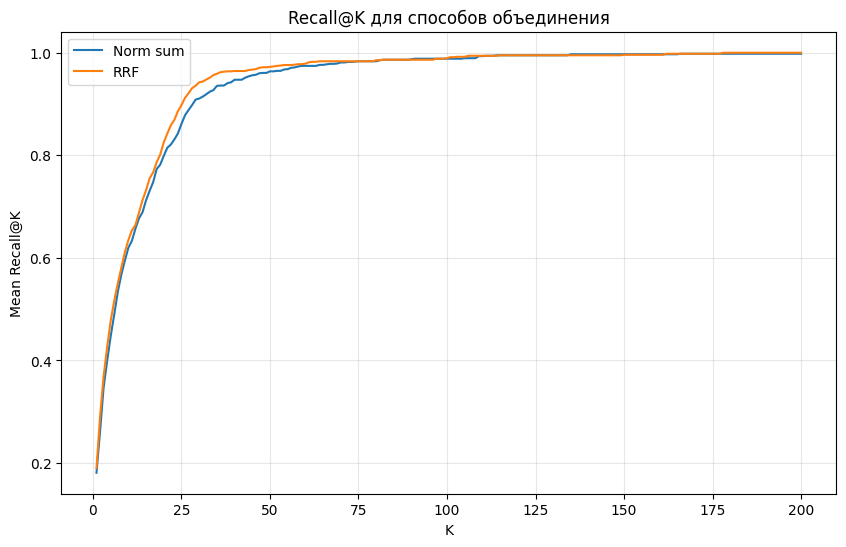

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ground_truth = {
    row.query_id: {int(x) for x in str(row.ground_truth).split()}
    for row in calibration.itertuples(index=False)
}

# Если RRF ещё не рассчитан
for col in score_cols:
    scores_exp[f"{col}_rank"] = (
        scores_exp.groupby("query_id")[col]
        .rank(method="min", ascending=False)
    )

RRF_K = 60

scores_exp["rrf_score"] = sum(
    1 / (RRF_K + scores_exp[f"{col}_rank"])
    for col in score_cols
)


def recall_curve(ranked_df, score_col, ks):
    ranked = (
        ranked_df
        .sort_values(
            ["query_id", score_col],
            ascending=[True, False],
        )
        .groupby("query_id")["article_id"]
        .apply(list)
        .to_dict()
    )

    recalls = []

    for k in ks:
        query_recalls = []

        for query_id, relevant in ground_truth.items():
            retrieved = set(ranked.get(query_id, [])[:k])
            query_recalls.append(
                len(relevant & retrieved) / len(relevant)
            )

        recalls.append(np.mean(query_recalls))

    return np.array(recalls)


ks = np.arange(1, 201)

recall_norm = recall_curve(scores_exp, "norm_sum", ks)
recall_rrf = recall_curve(scores_exp, "rrf_score", ks)

plt.figure(figsize=(10, 6))
plt.plot(ks, recall_norm, label="Norm sum")
plt.plot(ks, recall_rrf, label="RRF")
plt.xlabel("K")
plt.ylabel("Mean Recall@K")
plt.title("Recall@K для способов объединения")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Recall для union top-N

Отдельно смотрю сколько кандидатов получается при объединении выдач и какой recall это дает. Такой способ очень надежный но пул быстро раздувается.


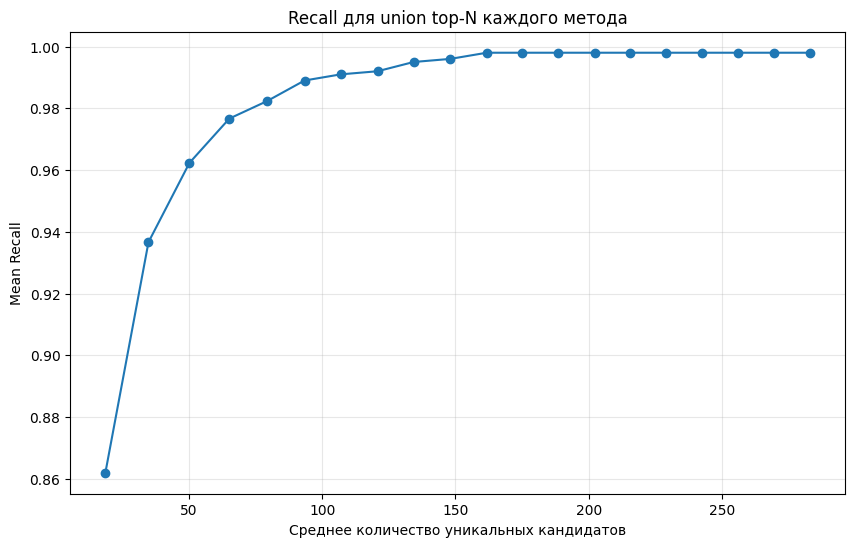

In [ ]:
union_ns = list(range(5, 101, 5))

union_results = []

for n in union_ns:
    parts = []

    for col in score_cols:
        top_n = (
            scores
            .sort_values(
                ["query_id", col],
                ascending=[True, False],
            )
            .groupby("query_id")
            .head(n)[["query_id", "article_id"]]
        )

        parts.append(top_n)

    union_candidates = (
        pd.concat(parts, ignore_index=True)
        .drop_duplicates(["query_id", "article_id"])
    )

    candidate_sets = (
        union_candidates
        .groupby("query_id")["article_id"]
        .apply(set)
        .to_dict()
    )

    pool_sizes = (
        union_candidates
        .groupby("query_id")
        .size()
    )

    query_recalls = []

    for query_id, relevant in ground_truth.items():
        retrieved = candidate_sets.get(query_id, set())

        query_recalls.append(
            len(relevant & retrieved) / len(relevant)
        )

    union_results.append({
        "top_n_each": n,
        "mean_pool_size": pool_sizes.mean(),
        "recall": np.mean(query_recalls),
    })

union_curve = pd.DataFrame(union_results)

plt.figure(figsize=(10, 6))
plt.plot(
    union_curve["mean_pool_size"],
    union_curve["recall"],
    marker="o",
)
plt.xlabel("Среднее количество уникальных кандидатов")
plt.ylabel("Mean Recall")
plt.title("Recall для union top-N каждого метода")
plt.grid(True, alpha=0.3)
plt.show()

## Точные значения Recall@100

Вывожу значения без графика чтобы было проще сравнить.


In [ ]:
print("Norm Recall@100:", recall_norm[99])
print("RRF Recall@100:", recall_rrf[99])

Norm Recall@100: 0.9883333333333333
RRF Recall@100: 0.9893333333333333


**Итого:** RRF немного лучше суммы нормализованных скоров на Recall@100 (`0.9893` против `0.9883`). Разница небольшая но RRF не требует подбора весов.

# 6. MAP@10 и анализ отдельных сигналов

Сначала реализую метрику ровно в том виде в котором она считается в задаче. Если релевантных статей несколько учитывается их порядок и количество найденных документов.


In [ ]:
ground_truth = {
    row.query_id: {int(x) for x in str(row.ground_truth).split()}
    for row in calibration.itertuples(index=False)
}


def map_at_k(ranked_df, score_col, k=10):
    predictions = (
        ranked_df
        .sort_values(
            ["query_id", score_col],
            ascending=[True, False],
        )
        .groupby("query_id")
        .head(k)
        .groupby("query_id")["article_id"]
        .apply(list)
        .to_dict()
    )

    average_precisions = []

    for query_id, relevant in ground_truth.items():
        predicted = predictions.get(query_id, [])

        hits = 0
        ap = 0.0

        for rank, article_id in enumerate(predicted, start=1):
            if article_id in relevant:
                hits += 1
                ap += hits / rank

        ap /= min(len(relevant), k)
        average_precisions.append(ap)

    return np.mean(average_precisions)

## RRF как финальный ранжировщик

Проверяю что будет если просто взять общий RRF и сразу вернуть top-10 без обучаемого реранкера.


In [ ]:
rrf_map10 = map_at_k(
    scores_exp,
    score_col="rrf_score",
    k=10,
)

print("RRF MAP@10:", rrf_map10)

RRF MAP@10: 0.33733439153439154


## Сумма нормализованных скоров

Для полноты сравниваю с предыдущим способом объединения.


In [ ]:
norm_map10 = map_at_k(
    scores_exp,
    score_col="norm_sum",
    k=10,
)

print("Norm sum MAP@10:", norm_map10)

Norm sum MAP@10: 0.3196977513227513


**Вывод по простому объединению.** RRF дает `0.3373`, norm sum — `0.3197`. Для финальной выдачи этого мало поэтому дальше нужен более сильный реранкер.

## Качество каждого сигнала отдельно

Это полезно чтобы понять где вообще лежит основной сигнал и какие признаки скорее дополняют друг друга.


In [ ]:
single_results = []

for col in score_cols:
    score = map_at_k(
        scores_exp,
        score_col=col,
        k=10,
    )

    single_results.append({
        "signal": col,
        "MAP@10": score,
    })

single_results = (
    pd.DataFrame(single_results)
    .sort_values("MAP@10", ascending=False)
    .reset_index(drop=True)
)

single_results

,signal,MAP@10
0,chunk_qwen,0.483499
1,chunk_char,0.381316
2,chunk_bm25,0.314648
3,title_qwen,0.168868
4,title_char,0.157166
5,title_bm25,0.128994


**Главный вывод.** Самый сильный одиночный сигнал — `chunk_qwen` с `0.4835`. Все title-признаки заметно слабее. Это ожидаемо потому что пользовательский вопрос часто совпадает с конкретным разделом статьи а не с ее коротким названием.

## RRF только по chunk-признакам

После анализа одиночных методов отдельно объединяю самые полезные chunk скоры. Заголовки сами по себе слабые а в чанках находится основной смысл статьи.


In [ ]:
temp = scores.copy()

# Ранги внутри каждого запроса
temp["qwen_rank"] = (
    temp.groupby("query_id")["chunk_qwen"]
    .rank(method="min", ascending=False)
)

temp["char_rank"] = (
    temp.groupby("query_id")["chunk_char"]
    .rank(method="min", ascending=False)
)

temp["bm25_rank"] = (
    temp.groupby("query_id")["chunk_bm25"]
    .rank(method="min", ascending=False)
)

# RRF: Qwen + char
temp["rrf_qwen_char"] = (
    1 / (60 + temp["qwen_rank"])
    + 1 / (60 + temp["char_rank"])
)

# RRF: Qwen + BM25
temp["rrf_qwen_bm25"] = (
    1 / (60 + temp["qwen_rank"])
    + 1 / (60 + temp["bm25_rank"])
)

# RRF: все три
temp["rrf_all_chunks"] = (
    1 / (60 + temp["qwen_rank"])
    + 1 / (60 + temp["char_rank"])
    + 1 / (60 + temp["bm25_rank"])
)

print("Только Qwen:", map_at_k(temp, "chunk_qwen", 10))
print("Qwen + char:", map_at_k(temp, "rrf_qwen_char", 10))
print("Qwen + BM25:", map_at_k(temp, "rrf_qwen_bm25", 10))
print("Qwen + char + BM25:", map_at_k(temp, "rrf_all_chunks", 10))

Только Qwen: 0.4834988095238094
Qwen + char: 0.5159308201058201
Qwen + BM25: 0.4935502645502646
Qwen + char + BM25: 0.5132027777777778


**Результат.** Лучший простой вариант — Qwen + char TF-IDF: `0.51593`. BM25 тоже добавляет новые документы но в финальном top-10 немного просаживает качество. Для candidate pool все три сигнала все равно полезны потому что там важнее recall.

# 7. CatBoost-реранкер

Функция для оценки одного validation fold. Она сортирует кандидатов по нужному скору и считает `MAP@10` только для запросов текущего фолда.


In [ ]:
def val_map10(df, score_col):
    predictions = (
        df.sort_values(
            ["query_id", score_col],
            ascending=[True, False]
        )
        .groupby("query_id")
        .head(10)
        .groupby("query_id")["article_id"]
        .apply(list)
        .to_dict()
    )

    scores = []

    for query_id in val_ids:
        relevant = ground_truth[query_id]
        hits = 0
        ap = 0

        for rank, article_id in enumerate(
            predictions.get(query_id, []), start=1
        ):
            if article_id in relevant:
                hits += 1
                ap += hits / rank

        scores.append(ap / min(len(relevant), 10))

    return np.mean(scores)



## Базовый CatBoostRanker

Берется top-100 кандидатов по `rrf_all_chunks`. Для каждой пары запрос-статья создается бинарный label и CatBoost учится ранжировать статьи внутри одного `query_id`.

Первый запуск идет только на шести сырых признаках.


In [ ]:
# Top-100 кандидатов
data = (
    temp.sort_values(
        ["query_id", "rrf_all_chunks"],
        ascending=[True, False]
    )
    .groupby("query_id")
    .head(100)
    .copy()
)

data["label"] = [
    int(article_id in ground_truth[query_id])
    for query_id, article_id
    in zip(data["query_id"], data["article_id"])
]

features = [
    "title_bm25",
    "title_char",
    "chunk_bm25",
    "chunk_char",
    "title_qwen",
    "chunk_qwen",
]

query_ids = data["query_id"].unique()

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

results = []

for fold, (train_idx, val_idx) in enumerate(kf.split(query_ids), start=1):

    train_ids = query_ids[train_idx]
    val_ids = query_ids[val_idx]

    train = (
        data[data["query_id"].isin(train_ids)]
        .sort_values("query_id")
        .copy()
    )

    val = (
        data[data["query_id"].isin(val_ids)]
        .sort_values("query_id")
        .copy()
    )

    train_pool = Pool(
        train[features],
        label=train["label"],
        group_id=train["query_id"],
    )

    val_pool = Pool(
        val[features],
        label=val["label"],
        group_id=val["query_id"],
    )

    model = CatBoostRanker(
        iterations=1000,
        depth=6,
        learning_rate=0.05,
        loss_function="YetiRankPairwise",
        eval_metric="NDCG:top=10",
        random_seed=42,
        verbose=False,
    )

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=100,
    )

    val["boost_score"] = model.predict(val[features])

    rrf_score = val_map10(val, "rrf_qwen_char")
    boost_score = val_map10(val, "boost_score")

    results.append({
        "fold": fold,
        "RRF": rrf_score,
        "Boost": boost_score,
    })

    print(
        f"Fold {fold}: "
        f"RRF={rrf_score:.4f}, "
        f"Boost={boost_score:.4f}"
    )

Fold 1: RRF=0.4961, Boost=0.5671
Fold 2: RRF=0.5116, Boost=0.5159
Fold 3: RRF=0.4985, Boost=0.5461
Fold 4: RRF=0.5058, Boost=0.5795
Fold 5: RRF=0.5649, Boost=0.6144


## Итоги базового реранкера

Собираю результаты пяти фолдов в одну таблицу.


In [ ]:
results = pd.DataFrame(results)

display(results)

print("Средний RRF:", results["RRF"].mean())
print("Средний Boost:", results["Boost"].mean())
print("Boost std:", results["Boost"].std())

,fold,RRF,Boost
0,1,0.496060,0.567058
1,2,0.511633,0.515877
2,3,0.498516,0.546099
3,4,0.505829,0.579530
4,5,0.564895,0.614403


Средний RRF: 0.5153863756613756
Средний Boost: 0.5645935185185185
Boost std: 0.03682911391110683


**Результат.** Средний MAP@10 растет с `0.5154` у RRF до `0.5646` у CatBoost. Бустинг выиграл на всех пяти фолдах значит улучшение не держится на одном удачном split.

## Добавляем ранги и нормализацию

Сырые значения полезны но для ранжирования часто важнее позиция статьи относительно остальных кандидатов. Поэтому для каждого признака добавляю:

- ранг внутри запроса;
- min-max значение внутри запроса.

Код модели почти тот же меняется только набор фичей.


In [ ]:
# Top-100 кандидатов
data = (
    temp.sort_values(
        ["query_id", "rrf_all_chunks"],
        ascending=[True, False]
    )
    .groupby("query_id")
    .head(100)
    .copy()
)

data["label"] = [
    int(article_id in ground_truth[query_id])
    for query_id, article_id
    in zip(data["query_id"], data["article_id"])
]

base_features = [
    "title_bm25",
    "title_char",
    "chunk_bm25",
    "chunk_char",
    "title_qwen",
    "chunk_qwen",
]

# Ранги и нормализованные значения внутри каждого запроса
for col in base_features:
    group = data.groupby("query_id")[col]

    data[f"{col}_rank"] = group.rank(
        method="average",
        ascending=False
    )

    col_min = group.transform("min")
    col_max = group.transform("max")

    data[f"{col}_norm"] = (
        (data[col] - col_min)
        / (col_max - col_min + 1e-12)
    )

features = (
    base_features
    + [f"{col}_rank" for col in base_features]
    + [f"{col}_norm" for col in base_features]
)

query_ids = data["query_id"].unique()

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

results = []

for fold, (train_idx, val_idx) in enumerate(
    kf.split(query_ids),
    start=1
):
    train_ids = query_ids[train_idx]
    val_ids = query_ids[val_idx]

    train = (
        data[data["query_id"].isin(train_ids)]
        .sort_values("query_id")
        .copy()
    )

    val = (
        data[data["query_id"].isin(val_ids)]
        .sort_values("query_id")
        .copy()
    )

    train_pool = Pool(
        train[features],
        label=train["label"],
        group_id=train["query_id"],
    )

    val_pool = Pool(
        val[features],
        label=val["label"],
        group_id=val["query_id"],
    )

    model = CatBoostRanker(
        iterations=1000,
        depth=6,
        learning_rate=0.05,
        loss_function="YetiRankPairwise",
        eval_metric="NDCG:top=10",
        random_seed=42,
        verbose=False,
    )

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=100,
    )

    val["boost_score"] = model.predict(val[features])

    rrf_score = val_map10(val, "rrf_qwen_char")
    boost_score = val_map10(val, "boost_score")

    results.append({
        "fold": fold,
        "RRF": rrf_score,
        "Boost": boost_score,
    })

    print(
        f"Fold {fold}: "
        f"RRF={rrf_score:.4f}, "
        f"Boost={boost_score:.4f}"
    )

results_df = pd.DataFrame(results)

print("Средний RRF:", results_df["RRF"].mean())
print("Средний Boost:", results_df["Boost"].mean())
print("Boost std:", results_df["Boost"].std())

Fold 1: RRF=0.4961, Boost=0.6351
Fold 2: RRF=0.5116, Boost=0.5285
Fold 3: RRF=0.4985, Boost=0.5776
Fold 4: RRF=0.5058, Boost=0.5988
Fold 5: RRF=0.5649, Boost=0.6240
Средний RRF: 0.5153863756613756
Средний Boost: 0.5927825396825398
Boost std: 0.042318958191467665


**Это основной прирост.** После добавления относительных признаков средний MAP@10 стал `0.59278`. Видимо модели реально важно не только значение скора но и насколько статья выше остальных внутри конкретного запроса.

## Эксперимент с оптимизацией MAP

Пробую `YetiRankPairwise:mode=MAP;top=10` на CPU. Идея логичная потому что целевая метрика тоже MAP@10 но на практике обычный `YetiRankPairwise` выше.


In [ ]:
query_ids = data["query_id"].unique()

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

results = []
models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(query_ids), start=1):

    train_ids = query_ids[train_idx]
    val_ids = query_ids[val_idx]

    train = (
        data[data["query_id"].isin(train_ids)]
        .sort_values("query_id")
        .copy()
    )

    val = (
        data[data["query_id"].isin(val_ids)]
        .sort_values("query_id")
        .copy()
    )

    train_pool = Pool(
        train[features],
        label=train["label"],
        group_id=train["query_id"],
    )

    val_pool = Pool(
        val[features],
        label=val["label"],
        group_id=val["query_id"],
    )

    model = CatBoostRanker(
        iterations=1000,
        depth=6,
        learning_rate=0.05,
        loss_function="YetiRankPairwise:mode=MAP;top=10",
        eval_metric="MAP:top=10",
        task_type="CPU",
        random_seed=42,
        verbose=False,
    )

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=100,
    )

    val["boost_score"] = model.predict(val[features])

    rrf_score = val_map10(val, "rrf_qwen_char")
    boost_score = val_map10(val, "boost_score")

    results.append({
        "fold": fold,
        "RRF": rrf_score,
        "Boost": boost_score,
        "best_iteration": model.get_best_iteration(),
    })

    models.append(model)

    print(
        f"Fold {fold}: "
        f"RRF={rrf_score:.4f}, "
        f"Boost={boost_score:.4f}"
    )

results_df = pd.DataFrame(results)

display(results_df)

print("Средний RRF:", results_df["RRF"].mean())
print("Средний Boost:", results_df["Boost"].mean())
print("Boost std:", results_df["Boost"].std())

Fold 1: RRF=0.4961, Boost=0.5993
Fold 2: RRF=0.5116, Boost=0.5353
Fold 3: RRF=0.4985, Boost=0.5654
Fold 4: RRF=0.5058, Boost=0.5745
Fold 5: RRF=0.5649, Boost=0.6178


,fold,RRF,Boost,best_iteration
0,1,0.496060,0.599345,155
1,2,0.511633,0.535317,137
2,3,0.498516,0.565440,297
3,4,0.505829,0.574522,330
4,5,0.564895,0.617769,216


Средний RRF: 0.5153863756613756
Средний Boost: 0.5784787037037036
Boost std: 0.0317318727739326


**Результат эксперимента.** MAP-режим дал `0.57848`, то есть ниже обычного YetiRankPairwise с рангами и нормализацией. Поэтому эту версию не выбираю как основную.

# 8. Применение пайплайна к test (финальный сабмит)

Здесь полностью повторяется расчет признаков для `test.f`: очистка запросов BM25 char TF-IDF и Qwen. Важно что статьи и их эмбеддинги уже готовы поэтому повторно кодируются только тестовые запросы.

Ниже также обучается одна модель на всем calibration и создается первый вариант сабмита с top-100 кандидатами.


In [ ]:
TEST_PATH = ("/kaggle/input/datasets/ivanbrazil/candidate-data/candidate_public/candidate_data/test.f")

test = pd.read_feather(TEST_PATH)

raw_test_queries = test["query_text"].fillna("").astype(str)
test_queries = raw_test_queries.apply(clean_query)



test_title_bm25, test_title_char = score_corpus(
    title_docs["title_text"],
    test_queries,
)

test_chunk_bm25, test_chunk_char = score_corpus(
    chunk_docs["search_text"],
    test_queries,
)

test_title_scores = pd.DataFrame({
    "query_id": np.repeat(
        test["query_id"].to_numpy(),
        len(title_docs),
    ),
    "article_id": np.tile(
        title_docs["article_id"].to_numpy(),
        len(test),
    ),
    "title_bm25": test_title_bm25.ravel(),
    "title_char": test_title_char.ravel(),
})

test_chunk_scores = pd.DataFrame({
    "query_id": np.repeat(
        test["query_id"].to_numpy(),
        len(chunk_docs),
    ),
    "article_id": np.tile(
        chunk_docs["article_id"].to_numpy(),
        len(test),
    ),
    "chunk_bm25": test_chunk_bm25.ravel(),
    "chunk_char": test_chunk_char.ravel(),
})

test_chunk_scores = (
    test_chunk_scores
    .groupby(
        ["query_id", "article_id"],
        as_index=False,
    )[["chunk_bm25", "chunk_char"]]
    .max()
)



test_query_embeddings = qwen.encode(
    test_queries.tolist(),
    prompt_name="query",
    batch_size=16,
    normalize_embeddings=True,
    convert_to_numpy=True,
    show_progress_bar=True,
)

test_title_qwen = test_query_embeddings @ title_embeddings.T
test_chunk_qwen = test_query_embeddings @ chunk_embeddings.T

test_title_qwen_scores = pd.DataFrame({
    "query_id": np.repeat(
        test["query_id"].to_numpy(),
        len(title_docs),
    ),
    "article_id": np.tile(
        title_docs["article_id"].to_numpy(),
        len(test),
    ),
    "title_qwen": test_title_qwen.ravel(),
})

test_chunk_qwen_scores = pd.DataFrame({
    "query_id": np.repeat(
        test["query_id"].to_numpy(),
        len(chunk_docs),
    ),
    "article_id": np.tile(
        chunk_docs["article_id"].to_numpy(),
        len(test),
    ),
    "chunk_qwen": test_chunk_qwen.ravel(),
})

test_chunk_qwen_scores = (
    test_chunk_qwen_scores
    .groupby(
        ["query_id", "article_id"],
        as_index=False,
    )["chunk_qwen"]
    .max()
)



scores_test = (
    test_title_scores
    .merge(
        test_chunk_scores,
        on=["query_id", "article_id"],
        how="left",
    )
    .merge(
        test_title_qwen_scores,
        on=["query_id", "article_id"],
        how="left",
    )
    .merge(
        test_chunk_qwen_scores,
        on=["query_id", "article_id"],
        how="left",
    )
    .fillna(0)
)



temp_test = scores_test.copy()

temp_test["qwen_rank"] = (
    temp_test.groupby("query_id")["chunk_qwen"]
    .rank(method="min", ascending=False)
)

temp_test["char_rank"] = (
    temp_test.groupby("query_id")["chunk_char"]
    .rank(method="min", ascending=False)
)

temp_test["bm25_rank"] = (
    temp_test.groupby("query_id")["chunk_bm25"]
    .rank(method="min", ascending=False)
)

temp_test["rrf_all_chunks"] = (
    1 / (60 + temp_test["qwen_rank"])
    + 1 / (60 + temp_test["char_rank"])
    + 1 / (60 + temp_test["bm25_rank"])
)



base_features = [
    "title_bm25",
    "title_char",
    "chunk_bm25",
    "chunk_char",
    "title_qwen",
    "chunk_qwen",
]


def prepare_data(df):
    df = (
        df.sort_values(
            ["query_id", "rrf_all_chunks"],
            ascending=[True, False],
        )
        .groupby("query_id")
        .head(100)
        .copy()
    )

    for col in base_features:
        group = df.groupby("query_id")[col]

        df[f"{col}_rank"] = group.rank(
            method="average",
            ascending=False,
        )

        col_min = group.transform("min")
        col_max = group.transform("max")

        df[f"{col}_norm"] = (
            (df[col] - col_min)
            / (col_max - col_min + 1e-12)
        )

    return df


features = (
    base_features
    + [f"{col}_rank" for col in base_features]
    + [f"{col}_norm" for col in base_features]
)



ground_truth = {
    row.query_id: {
        int(x) for x in str(row.ground_truth).split()
    }
    for row in calibration.itertuples(index=False)
}

train_data = prepare_data(temp)

train_data["label"] = [
    int(article_id in ground_truth[query_id])
    for query_id, article_id in zip(
        train_data["query_id"],
        train_data["article_id"],
    )
]

train_data = (
    train_data
    .sort_values("query_id")
    .reset_index(drop=True)
)

train_pool = Pool(
    train_data[features],
    label=train_data["label"],
    group_id=train_data["query_id"],
)

final_model = CatBoostRanker(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="YetiRankPairwise",
    random_seed=42,
    verbose=100,
)

final_model.fit(train_pool)



test_data = prepare_data(temp_test)

test_data["boost_score"] = final_model.predict(
    test_data[features]
)

submission = (
    test_data
    .sort_values(
        ["query_id", "boost_score"],
        ascending=[True, False],
    )
    .groupby("query_id")
    .head(10)
    .groupby("query_id")["article_id"]
    .apply(lambda ids: " ".join(ids.astype(str)))
    .reset_index()
)

submission = test[["query_id"]].merge(
    submission,
    on="query_id",
    how="left",
)

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False,
)


print("Готово")
display(submission.head())

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

0:	total: 72.5ms	remaining: 21.7s
100:	total: 7.27s	remaining: 14.3s
200:	total: 14.4s	remaining: 7.09s
299:	total: 21.4s	remaining: 0us
Готово


,query_id,article_id
0,1,4308 1899 4356 4435 4234 4331 2511 4396 1901 2222
1,2,2408 1966 4234 3209 2944 2521 2802 4009 3843 1923
2,3,1909 4234 4396 4331 1910 4446 4219 4516 2646 4286
3,4,4234 4361 1966 2865 4400 2646 4403 4331 4532 2866
4,5,4308 4356 4435 4320 3467 3168 2698 4214 3265 4234


## Формат финального файла

Пересобираю таблицу с правильным названием колонки `answer`: в каждой строке лежат 10 числовых `article_id` через пробел.


In [ ]:
submission = (
    test_data
    .sort_values(
        ["query_id", "boost_score"],
        ascending=[True, False],
    )
    .groupby("query_id")
    .head(10)
    .groupby("query_id")["article_id"]
    .apply(lambda ids: " ".join(str(int(x)) for x in ids))
    .reset_index(name="answer")
)

submission = (
    test[["query_id"]]
    .merge(submission, on="query_id", how="left")
)

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False,
)

display(submission.head())

,query_id,answer
0,1,4308 1899 4356 4435 4234 4331 2511 4396 1901 2222
1,2,2408 1966 4234 3209 2944 2521 2802 4009 3843 1923
2,3,1909 4234 4396 4331 1910 4446 4219 4516 2646 4286
3,4,4234 4361 1966 2865 4400 2646 4403 4331 4532 2866
4,5,4308 4356 4435 4320 3467 3168 2698 4214 3265 4234


## Проверка сабмита

Проверяю число строк уникальность `query_id`, отсутствие пропусков и ровно 10 ответов в каждой строке.


In [ ]:
assert len(submission) == len(test)
assert submission["query_id"].is_unique
assert submission["answer"].notna().all()
assert submission["answer"].str.split().str.len().eq(10).all()

Все проверки проходят. Значит файл технически валидный: 500 запросов и по 10 статей на каждый.

# 9. Дополнительные эксперименты

## Ансамбль CatBoost моделей

Обучаю пять моделей на разных фолдах и усредняю их предсказания на test. Еще добавляю `rrf_all_chunks` как отдельный признак.

Это нормальная гипотеза на стабильность но сам факт усреднения не гарантирует прирост если модели очень похожи.


In [ ]:
ground_truth = {
    row.query_id: {
        int(article_id)
        for article_id in str(row.ground_truth).split()
    }
    for row in calibration.itertuples(index=False)
}


base_features = [
    "title_bm25",
    "title_char",
    "chunk_bm25",
    "chunk_char",
    "title_qwen",
    "chunk_qwen",
]


def prepare_data(df):
    # Оставляем top-100 кандидатов по RRF
    result = (
        df.sort_values(
            ["query_id", "rrf_all_chunks"],
            ascending=[True, False],
        )
        .drop_duplicates(["query_id", "article_id"])
        .groupby("query_id")
        .head(100)
        .copy()
    )

    # Ранги и нормализация внутри каждого запроса
    for col in base_features:
        group = result.groupby("query_id")[col]

        result[f"{col}_rank"] = group.rank(
            method="average",
            ascending=False,
        )

        col_min = group.transform("min")
        col_max = group.transform("max")

        result[f"{col}_norm"] = (
            (result[col] - col_min)
            / (col_max - col_min + 1e-12)
        )

    return result


# Старые признаки + сам RRF
features = (
    base_features
    + [f"{col}_rank" for col in base_features]
    + [f"{col}_norm" for col in base_features]
    + ["rrf_all_chunks"]
)




train_data = prepare_data(temp)

train_data["label"] = [
    int(article_id in ground_truth[query_id])
    for query_id, article_id in zip(
        train_data["query_id"],
        train_data["article_id"],
    )
]

train_data = (
    train_data
    .sort_values("query_id")
    .reset_index(drop=True)
)

test_data = prepare_data(temp_test)



query_ids = train_data["query_id"].unique()

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

models = []
best_iterations = []

for fold, (train_idx, val_idx) in enumerate(
    kf.split(query_ids),
    start=1,
):
    train_ids = query_ids[train_idx]
    val_ids = query_ids[val_idx]

    fold_train = (
        train_data[
            train_data["query_id"].isin(train_ids)
        ]
        .sort_values("query_id")
        .copy()
    )

    fold_val = (
        train_data[
            train_data["query_id"].isin(val_ids)
        ]
        .sort_values("query_id")
        .copy()
    )

    train_pool = Pool(
        fold_train[features],
        label=fold_train["label"],
        group_id=fold_train["query_id"],
    )

    val_pool = Pool(
        fold_val[features],
        label=fold_val["label"],
        group_id=fold_val["query_id"],
    )

    model = CatBoostRanker(
        iterations=1000,
        depth=6,
        learning_rate=0.05,
        loss_function="YetiRankPairwise",
        eval_metric="NDCG:top=10",
        random_seed=42 + fold,
        verbose=False,
    )

    model.fit(
        train_pool,
        eval_set=val_pool,
        early_stopping_rounds=100,
    )

    models.append(model)
    best_iterations.append(model.get_best_iteration())

    print(
        f"Fold {fold} готов, "
        f"best_iteration={model.get_best_iteration()}"
    )



test_predictions = np.column_stack([
    model.predict(test_data[features])
    for model in models
])

test_data["boost_score"] = test_predictions.mean(axis=1)

print(
    "Средний best_iteration:",
    np.mean(best_iterations),
)


submission = (
    test_data
    .sort_values(
        ["query_id", "boost_score"],
        ascending=[True, False],
    )
    .drop_duplicates(["query_id", "article_id"])
    .groupby("query_id")
    .head(10)
    .groupby("query_id")["article_id"]
    .apply(
        lambda ids: " ".join(
            str(int(article_id))
            for article_id in ids
        )
    )
    .reset_index(name="answer")
)

# Сохраняем исходный порядок test
submission = (
    test[["query_id"]]
    .merge(
        submission,
        on="query_id",
        how="left",
    )
)



assert len(submission) == len(test)
assert submission["query_id"].is_unique
assert submission["answer"].notna().all()
assert submission["answer"].str.split().str.len().eq(10).all()

assert submission["answer"].apply(
    lambda answer: (
        len(answer.split())
        == len(set(answer.split()))
    )
).all()




output_path = "/kaggle/working/answer.csv"

submission.to_csv(
    output_path,
    index=False,
)

print("Готово:", output_path)

Fold 1 готов, best_iteration=240
Fold 2 готов, best_iteration=144
Fold 3 готов, best_iteration=195
Fold 4 готов, best_iteration=877
Fold 5 готов, best_iteration=103
Средний best_iteration: 311.8
Готово: /kaggle/working/answer.csv


**Что тут проверяется.** Ансамбль может уменьшить случайность отдельных моделей но он обучается на почти одинаковых данных и признаках. Поэтому сильного прироста от него ждать не обязательно.

## Подбор размера candidate pool

Сравниваю `top-30`, `top-50`, `top-70` и `top-100` в одинаковой 5-fold схеме. Тут меняется только число статей которые CatBoost видит для каждого запроса.


In [ ]:
top_results = {}

for top_k in [30, 50, 70, 100]:

    data_k = (
        temp.sort_values(
            ["query_id", "rrf_all_chunks"],
            ascending=[True, False],
        )
        .groupby("query_id")
        .head(top_k)
        .copy()
    )

    data_k["label"] = [
        int(a in ground_truth[q])
        for q, a in zip(data_k["query_id"], data_k["article_id"])
    ]

    for col in base_features:
        g = data_k.groupby("query_id")[col]

        data_k[f"{col}_rank"] = g.rank(
            method="average",
            ascending=False,
        )

        mn = g.transform("min")
        mx = g.transform("max")

        data_k[f"{col}_norm"] = (
            (data_k[col] - mn) / (mx - mn + 1e-12)
        )

    features_k = (
        base_features
        + [f"{c}_rank" for c in base_features]
        + [f"{c}_norm" for c in base_features]
    )

    query_ids = data_k["query_id"].unique()
    fold_scores = []

    for train_idx, val_idx in KFold(
        n_splits=5,
        shuffle=True,
        random_state=42,
    ).split(query_ids):

        train_ids = query_ids[train_idx]
        val_ids = query_ids[val_idx]

        train = (
            data_k[data_k["query_id"].isin(train_ids)]
            .sort_values("query_id")
        )

        val = (
            data_k[data_k["query_id"].isin(val_ids)]
            .sort_values("query_id")
            .copy()
        )

        model = CatBoostRanker(
            iterations=1000,
            depth=6,
            learning_rate=0.05,
            loss_function="YetiRankPairwise",
            eval_metric="NDCG:top=10",
            random_seed=42,
            verbose=False,
        )

        model.fit(
            Pool(
                train[features_k],
                train["label"],
                group_id=train["query_id"],
            ),
            eval_set=Pool(
                val[features_k],
                val["label"],
                group_id=val["query_id"],
            ),
            early_stopping_rounds=100,
        )

        val["score"] = model.predict(val[features_k])
        fold_scores.append(val_map10(val, "score"))

    top_results[top_k] = np.mean(fold_scores)
    print(top_k, top_results[top_k])

30 0.5958456349206349
50 0.5875677248677248
70 0.5801580687830687
100 0.5927825396825398


**Результат.** Лучшим оказался top-30 с `0.59585`. Top-100 совсем рядом (`0.59278`) но более маленький пул дает модели меньше очевидно нерелевантных статей и чуть лучше фокусирует обучение.

# 10. Еще один эксперимент

По результатам прошлого эксперимента выбираю top-30 кандидатов. Это лучший локальный вариант:

- top-30 — `0.59585`;
- top-50 — `0.58757`;
- top-70 — `0.58016`;
- top-100 — `0.59278`.

На всем calibration обучается одна модель и потом строится итоговый `submission_top30.csv`.

В этой последней версии еще оставлен `rrf_all_chunks` как отдельная фича. Сам top-30 проверен на CV а влияние именно этой фичи отдельно тут не замерялось.


In [ ]:
ground_truth = {
    row.query_id: {int(x) for x in str(row.ground_truth).split()}
    for row in calibration.itertuples(index=False)
}

base_features = [
    "title_bm25",
    "title_char",
    "chunk_bm25",
    "chunk_char",
    "title_qwen",
    "chunk_qwen",
]


def prepare_data(df):
    df = (
        df.sort_values(
            ["query_id", "rrf_all_chunks"],
            ascending=[True, False],
        )
        .drop_duplicates(["query_id", "article_id"])
        .groupby("query_id")
        .head(30)
        .copy()
    )

    for col in base_features:
        group = df.groupby("query_id")[col]

        df[f"{col}_rank"] = group.rank(
            method="average",
            ascending=False,
        )

        col_min = group.transform("min")
        col_max = group.transform("max")

        df[f"{col}_norm"] = (
            (df[col] - col_min)
            / (col_max - col_min + 1e-12)
        )

    return df


features = (
    base_features
    + [f"{c}_rank" for c in base_features]
    + [f"{c}_norm" for c in base_features]
    + ["rrf_all_chunks"]
)

# Данные calibration
train_data = prepare_data(temp)

train_data["label"] = [
    int(article_id in ground_truth[query_id])
    for query_id, article_id in zip(
        train_data["query_id"],
        train_data["article_id"],
    )
]

train_data = (
    train_data
    .sort_values("query_id")
    .reset_index(drop=True)
)

# Данные test
test_data = prepare_data(temp_test)

# Обучение на всём calibration
train_pool = Pool(
    train_data[features],
    label=train_data["label"],
    group_id=train_data["query_id"],
)

final_model = CatBoostRanker(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="YetiRankPairwise",
    random_seed=42,
    verbose=100,
)

final_model.fit(train_pool)

# Предсказание
test_data["boost_score"] = final_model.predict(
    test_data[features]
)

# Top-10 статей по CatBoost
submission = (
    test_data
    .sort_values(
        ["query_id", "boost_score"],
        ascending=[True, False],
    )
    .groupby("query_id")
    .head(10)
    .groupby("query_id")["article_id"]
    .apply(lambda ids: " ".join(str(int(x)) for x in ids))
    .reset_index(name="answer")
)

# Возвращаем исходный порядок запросов
submission = test[["query_id"]].merge(
    submission,
    on="query_id",
    how="left",
)

# Проверки
assert len(submission) == len(test)
assert submission["query_id"].is_unique
assert submission["answer"].notna().all()
assert submission["answer"].str.split().str.len().eq(10).all()

# Сохранение
output_path = "/kaggle/working/submission_top30.csv"

submission.to_csv(
    output_path,
    index=False,
)

display(submission.head())

0:	total: 36.7ms	remaining: 11s
100:	total: 3.51s	remaining: 6.91s
200:	total: 6.99s	remaining: 3.44s
299:	total: 10.4s	remaining: 0us


,query_id,answer
0,1,4308 1899 4356 4435 2511 4234 1901 4331 2222 4394
1,2,2408 3209 1966 4234 2802 2944 3843 2521 1923 4009
2,3,1909 4234 4396 4446 4331 4516 4308 4219 4286 2065
3,4,4234 4361 1966 4400 2865 2646 4331 4532 4403 4219
4,5,4308 4356 4435 2698 4320 3168 4214 3467 4234 3265
